In [136]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)
from pileup_ml.compression.metrics import compare_matching_hits, compare_hit_presence

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm

# TODO:
# Use two matrices for VQ-VAE model lossy data compression
# Divide data into 4 x 4 batches
# Find embeddings using ADCS 4 x 4 batches
# scale patches into smaller scales

# Task:
# 1 patch'a - 1 pavyzdinis. Galima reguliuoti.
# Pasiimti viena event'a, nurodyti 8 x 8 patch'us ir kiekviena kvantuoti.


# Kiti darbai:
# Preprocessing acds reiksmiu. Clippint min ir max kokios gali buti.

In [137]:
SELECTED_EVENTS = 1
EVENT_COUNT = 1
PATCH_SIZE = 8
BITS_HIT = 25

In [ ]:
# Utillities
def show_image(events: np.array) -> None:
    image_plot = events.to_images()[0][1]
    plt.imshow(image_plot, cmap='gist_yarg', origin='lower')
    plt.show()
    
def plot_patch(patch: np.array, title: str) -> None:
    plt.imshow(patch, cmap='gist_yarg', origin='lower')
    plt.title(title)
    plt.show()
    
def _get_ssim_value(image1: np.array, image2: np.array) -> float:
    image2_min_value = image2.min()
    image2_max_value = image2.max()
    
    ssmi_value = ssim(
        image1, 
        image2, 
        data_range=image2_max_value - image2_min_value,
        win_size=3
    )
    
    return ssmi_value

def _tensor_to_numpy(values: torch.Tensor) -> np.array:
    return values.cpu().detach().numpy()

def plot_metric_results(
    y_values: list[float], 
    x_values: int, 
    y_title: str, 
    title: str,
    x_label: str,
    marker: str=None
) -> None:
    print(title + " values over epochs")
    plt.style.use('fivethirtyeight')
    plt.figure(figsize=(8, 5))
    plt.plot(x_values, y_values, marker=marker)
    plt.xlabel(x_label)
    plt.ylabel(y_title)
    plt.legend()
    plt.title(title)
    plt.show()
    
# def _get_4d_patch_tensor(patch: torch.tensor):
#     return torch.tensor(patch).\
#         unsqueeze(1)

def _get_vq_loss(recon_x: torch.tensor, x: torch.tensor, vq_loss: float) -> float:
    recon_loss = F.mse_loss(recon_x, x)
    return recon_loss + vq_loss

# TODO: kiek reikia bit'u uzkoduoti reiksmem. Paskaiciuoti pagal row, col, adcs reiksme.
# TODO: Minimalus bit'u kiekis apskaiciuoti bit'u. Pradziai turim hit'u sk * 1 bits * patch'u skaicius 
# TODO: 8 x 8, 

# def _get_bits_from_tensor(x: torch.tensor) -> float:
#     return (x.element_size() * x.numel()) * 8

# def _get_compression_ratio(a: torch.tensor, b: torch.tensor, precision: int) -> float:
#     a_bits = _get_bits_from_tensor(a)
#     b_bits = _get_bits_from_tensor(b)
    
#     print(f"a BITS: {a_bits}")
#     print(f"a dtype: {a.dtype}")
    
#     print(f"b BITS: {b_bits}")
#     print(f"b dtype: {b.dtype}")
    
#     return np.round(a_bits / b_bits, precision)

def event_hits_metrics(events: PixelDigiEvent, reconstructed_events: PixelDigiEvent) -> None:
    return {
        "rmse" : compare_matching_hits(events, reconstructed_events, metric='rmse'),
        'mae': compare_matching_hits(events, reconstructed_events, metric='mae'),
        'mismatch_ratio': compare_matching_hits(events, reconstructed_events, metric='mismatch_ratio'),
        'reco_precision_recall' : compare_hit_presence(events, reconstructed_events)
    }

# Based on formula 2.2, "Comparative study of compression algorithms on time series data for IoT devices"
def _get_patch_bits(num_embeddings: int, embedding_size: int) -> float:
    bits_per_index = np.ceil(np.log2(num_embeddings))
    total_encoding_bits = embedding_size * bits_per_index
    return total_encoding_bits

def _get_compression_ratio_hits(patch: torch.tensor, num_embeddings: int, embedding_size: int) -> float:
    image_bits = _get_bits_from_tensor(patch)
    result = image_bits / _get_patch_bits(num_embeddings, embedding_size)
    return result

In [139]:
def _get_patch_count(event: PixelDigiEvent) -> int:
    event_patches_adcs_flat = event_hits_to_patches(event, patch_size=PATCH_SIZE).as_array()
    event_patches_adcs = [
        event_patch_flat.reshape(PATCH_SIZE, PATCH_SIZE)
        for event_patch_flat in event_patches_adcs_flat
    ]
    return len(event_patches_adcs)

def _get_patch_adcs_from_event(event: PixelDigiEvent) -> torch.tensor:
    event_patches_adcs_flat = event_hits_to_patches(
        event, 
        patch_size=PATCH_SIZE
    ).as_array()
    event_patches_adcs = [
        event_patch_flat.reshape(PATCH_SIZE, PATCH_SIZE)
        for event_patch_flat in event_patches_adcs_flat
    ]
    return event_patches_adcs

In [140]:
# Moduliai ir ju savybes aprasomos pixel_modules json'uose
pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:04<00:00, 244.07it/s]


In [141]:
# Params
batch_size = 128
beta = 0.1 # commitment cost. Makes values more similar to the

# TODO: keep this fixed
# learning_rate = 1e-5
learning_rate = 1e-5

# num_epochs = 80
num_epochs = 80
channels = 1
latent_dim = 64
num_embeddings = 128  # Number of vectors in the codebook
# num_residual_hiddens = 3
# num_residual_layers = 2

# decay = 0.98
# vq_epsilon = 1e-5

LOG_EVERY = 10


In [142]:
# Selecting GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Applying seed for reproducability
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

device

device(type='cuda')

In [143]:
event_train = events_train[:SELECTED_EVENTS][0]


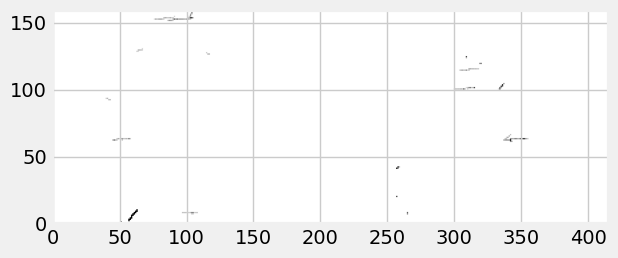

In [144]:
# plt.figure(figsize=(12, 6))
show_image(event_train)

In [145]:
class PixelPatchesDataset(torch.utils.data.Dataset):
    def __init__(self, event: PixelDigiEvent, transform=None):
        event_patches_adcs_flat = event_hits_to_patches(event, patch_size=PATCH_SIZE).as_array()
        self.event_patches_adcs = [
            event_patch_flat.reshape(PATCH_SIZE, PATCH_SIZE)
            for event_patch_flat in event_patches_adcs_flat
        ]
        self.transform = transform

    # Defining the length of the dataset
    def __len__(self) -> int:
        return len(self.event_patches_adcs)

    # Defining the method to get an item from the dataset
    def __getitem__(self, index: int) -> np.array:
        # print(self.event_patches_adcs[index])
        event_patch = self.event_patches_adcs[index]
        
        # Applying the transform
        if self.transform:
            event_patch = self.transform(event_patch)
            # print(event_patch)
        
        return event_patch

In [146]:
# X_patches_batches = torch.tensor(X_patches_batches).unsqueeze(1).float()
transform = transforms.Compose([
    transforms.ToTensor()
    # transforms.Normalize(mean=[0.5], std=[0.5])    
])

event_dataset = PixelPatchesDataset(event_train)

train_loader = DataLoader(
    dataset=event_dataset, 
    batch_size=batch_size
)

# Data preprocessing
events_test_loaders = []

for event_test in events_test:
    event_dataset = PixelPatchesDataset(event_test, transform)

    event_test_loader = DataLoader(
        dataset=event_dataset, 
        batch_size=batch_size
    )
    events_test_loaders.append(event_test_loader)

In [147]:
len(events_test_loaders[0])

67

In [148]:
len(event_test)

24791

In [149]:
data_sample = next(iter(train_loader))
data_sample.shape

torch.Size([128, 8, 8])

In [150]:
data_sample[0].dtype

torch.uint8

In [151]:
# next(iter(train_loader))

In [152]:
# patch_tensor = _get_4d_patch_tensor(data_sample[0])
# patch_tensor.shape

In [153]:
len(train_loader)

124

In [154]:
class VQEmbedding(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, beta: float) -> None:
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_embeddings = num_embeddings

        self.embedding = nn.Embedding(num_embeddings, embedding_dim)
        self.embedding.weight.data.normal_()
        self.beta = beta #commitment cost

    def forward(self, z):
        b, c, h, w = z.shape
        z_channel_last = z.permute(0, 2, 3, 1)
        z_flattened = z_channel_last.reshape(b*h*w, self.embedding_dim)

        # Calculate distances between z and the codebook embeddings |a-b|²
        # Euclidean distance. Form applied for efficiency in deep learning. In literature l2 distance is used.
        distances = (
            torch.sum(z_flattened ** 2, dim=-1, keepdim=True)                 # a²
            + torch.sum(self.embedding.weight.t() ** 2, dim=0, keepdim=True)  # b²
            - 2 * torch.matmul(z_flattened, self.embedding.weight.t())        # -2ab
        )

        # Get the index with the smallest distance
        # Finds minimum indexes at each row. Uses nearest neigboor look up
        encodings = torch.argmin(distances, dim=-1)

        # Get the quantized vector
        codebooks = self.embedding(encodings)
        # when we find the indexes feature vectors, we reshape them to the encoder latent 
        # representation shape
        z_q = codebooks.reshape(b, h, w,  self.embedding_dim)
        
        # changed the order of the reshaped z_q
        z_q = z_q.permute(0, 3, 1, 2)

        # Calculate the commitment loss
        # Measures how closely the encoder outputs and the selected codebook embeddings match each other.
        reconstruction_loss = F.mse_loss(z_q, z.detach())
        commitment_loss = F.mse_loss(z_q.detach(), z)
        loss = reconstruction_loss + self.beta * commitment_loss

        # Straight-through estimator trick for gradient backpropagation
        # Finding closer membership to indexes
        z_q = z + (z_q - z).detach()
        avg_probs = torch.mean(encodings.float(), dim=0)
        perplexity = torch.exp(-torch.sum(avg_probs * torch.log(avg_probs + 1e-10))) 

        return z_q, loss, perplexity, encodings, codebooks

In [155]:
# # NOTE: For bigger patches
# class VQEmbeddingV2(nn.Module):
#     def __init__(self, num_embeddings, embedding_dim, commitment_cost, decay, epsilon):
#         super().__init__()

#         self._num_embeddings = num_embeddings
#         self._embedding_dim = embedding_dim

#         self._embedding = nn.Embedding(self._num_embeddings, self._embedding_dim)
#         self._embedding.weight.data.normal_()
#         self._commitment_cost = commitment_cost

#         self.register_buffer('_ema_cluster_size', torch.zeros(num_embeddings))
#         self.register_buffer("_ema_w", self._embedding.weight.data.clone())
        
#         self._decay = decay
#         self._device = device
#         self._epsilon = epsilon

#     def forward(self, inputs):
#         """
#         Connects the module to some inputs.

#         Args:
#             inputs: Tensor, final dimension must be equal to embedding_dim. All other
#                 leading dimensions will be flattened and treated as a large batch.
        
#         Returns:
#             loss: Tensor containing the loss to optimize.
#             quantize: Tensor containing the quantized version of the input.
#             perplexity: Tensor containing the perplexity of the encodings.
#             encodings: Tensor containing the discrete encodings, ie which element
#                 of the quantized space each input element was mapped to.
#             distances
#         """

#         # Convert inputs from BCHW -> BHWC
#         # (1, 0, 2, 3
#         inputs = inputs.permute(0, 2, 3, 1).contiguous()
        
#         input_shape = inputs.shape
        
#         # Flatten input
#         flat_input = inputs.view(-1, self._embedding_dim)
        
#         # Compute distances between encoded audio frames and embedding vectors
#         distances = (torch.sum(flat_input**2, dim=1, keepdim=True) 
#                     + torch.sum(self._embedding.weight**2, dim=1)
#                     - 2 * torch.matmul(flat_input, self._embedding.weight.t()))

#         """
#         encoding_indices: Tensor containing the discrete encoding indices, ie
#         which element of the quantized space each input element was mapped to.
#         """
#         encoding_indices = torch.argmin(distances, dim=1).unsqueeze(1)
#         encodings = torch.zeros(encoding_indices.shape[0], self._num_embeddings, dtype=torch.float).to(self._device)
#         encodings.scatter_(1, encoding_indices, 1)


#         # Sample nearest embedding
#         # Use EMA to update the embedding vectors
#         if self.training:
#             with torch.no_grad():
#                 # EMA cluster size
                
#                 # controlls how smoothly the weights change
#                 self._ema_cluster_size.mul_(self._decay).add_(
#                     encodings.sum(0), alpha=1 - self._decay
#                 )

#                 # EMA embedding weights
#                 dw = torch.matmul(encodings.t(), flat_input)  # [K, C]
#                 self._ema_w.mul_(self._decay).add_(dw, alpha=1 - self._decay)

#                 # Laplace smoothing
#                 n = self._ema_cluster_size.sum()
#                 smoothed_cluster_size = (
#                     (self._ema_cluster_size + self._epsilon)
#                     / (n + self._num_embeddings * self._epsilon)
#                     * n
#                 )

#                 self._embedding.weight.data.copy_(
#                     self._ema_w / smoothed_cluster_size.unsqueeze(1)
#                 )

        
#         avg_probs = torch.mean(encodings, dim=0)
#         # Quantize and unflatten
#         quantized = torch.matmul(encodings, self._embedding.weight).view(input_shape)
#         # TODO: Check if the more readable self._embedding.weight.index_select(dim=1, index=encoding_indices) works better
#         # Loss
#         e_latent_loss = torch.mean((quantized.detach() - inputs)**2)
#         commitment_loss = self._commitment_cost * e_latent_loss        
#         quantized = inputs + (quantized - inputs).detach()
#         perplexity = torch.exp(-torch.sum(avg_probs * torch.log(avg_probs + 1e-10)))
#         """
#         The perplexity a useful value to track during training.
#         It indicates how many codes are 'active' on average.
#         """

#         quantized = quantized.view(input_shape)  # [B, H, W, C]
        
#         # print(quantized.shape)
        
#         quantized = quantized.permute(0, 3, 1, 2).contiguous()
#         # quantized = quantized.contiguous()
#         # Convert quantized from BHWC -> BCHW
#         return (
#             quantized, 
#             commitment_loss, 
#             perplexity,
#             encoding_indices,
#             encodings
#         )

In [156]:
def _get_encoded_patch_bits(encoded_size,
                           patch_size,
                           module_rows=160,
                           module_cols=416):
    
    encoded_width, encoded_height, num_embeddings = encoded_size
    vq_bits = encoded_width * encoded_height * np.log2(num_embeddings)
    
    # Patch address bits
    bits_patch_row = np.ceil(np.log2(np.ceil(module_rows / patch_size)))
    bits_patch_col = np.ceil(np.log2(np.ceil(module_cols / patch_size)))
    total = bits_patch_row + bits_patch_col + vq_bits
    return total.astype(np.uint8)

def _get_total_hit_bits(total_hits: int) -> int:
    
    # Patch address bits
    return total_hits * BITS_HIT

def _get_total_patch_bits(patch_amount: int, encoded_patch_size: tuple, patch_size: int) -> int:
    encoded_patch_bits = _get_encoded_patch_bits(encoded_patch_size, patch_size)
    return np.uint64(patch_amount) * encoded_patch_bits

# TODO: test the method
def _get_compression_ratio(n_hits_total: int, patch_amount: int, encoded_patch_size: tuple, patch_size: int) -> float:
    
    total_bits = _get_total_hit_bits(n_hits_total)
    total_patch_bits = _get_total_patch_bits(
        patch_amount, 
        encoded_patch_size, 
        patch_size
    )
    return total_bits / total_patch_bits

In [157]:
# class Residual(nn.Module):
#     """
#     Residual Convolutional Layer
#     """

#     def __init__(self, in_channels, num_residual_hiddens):
#         """
#         initialize residual CNN layer

#         :param in_channels number: Number of input channels
#         :param num_hiddens number: Number of hidden channels
#         :param num_residual_hiddens number: Number of residual hiddens
#         """
#         super(Residual, self).__init__()
#         self._block = nn.Sequential(
#             nn.ReLU(True),
#             # C: 3 -> residual hidden
#             nn.Conv2d(
#                 in_channels=in_channels,
#                 out_channels=num_residual_hiddens,
#                 kernel_size=3,
#                 stride=1,
#                 padding=1,
#                 bias=False,
#             ),
#             nn.ReLU(True),
#             # C: resiual hidden -> out_hidden
#             nn.Conv2d(
#                 in_channels=num_residual_hiddens,
#                 out_channels=in_channels,
#                 kernel_size=1,
#                 stride=1,
#                 bias=False,
#             ),
#         )

#     def forward(self, x):
#         """
#         Residual layer

#         :param x numpy.ndarray: Input image
#         """
#         return x + self._block(x)  # residual output


# class ResidualStack(nn.Module):
#     """
#     Residual Convolution Stack
#     """

#     def __init__(
#         self, in_channels, num_hiddens, num_residual_layers, num_residual_hiddens
#     ):
#         """
#         initialize residual stack

#         :param in_channels number: Number of input channels
#         :param num_hiddens number: Number of hidden channels
#         :param num_residual_layers number: Number of residual layers in stack
#         :param num_residual_hiddens number: Number of hidden residual channels
#         """
#         super(ResidualStack, self).__init__()
#         self._num_residual_layers = num_residual_layers
#         self._layers = nn.ModuleList(
#             [
#                 Residual(in_channels, num_hiddens, num_residual_hiddens)
#                 for _ in range(self._num_residual_layers)
#             ]
#         )

#     def forward(self, x):
#         """
#         Apply residual stack

#         :param x numpy.ndarray: Input image
#         """
#         # Apply all residual layers in stack
#         for i in range(self._num_residual_layers):
#             x = self._layers[i](x)
#         return F.relu(x)

In [158]:
# Updates
# Batch normalization reduced value shift by subtracting mean and deviding variance
# Also uses learnable parameters beta


class VQVAE(nn.Module):
    def __init__(self, hidden_channels: int, kernel_size: int, slope: float) -> None:
        super(VQVAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, hidden_channels, kernel_size=kernel_size - 1, stride=2, padding=1),  
            nn.LeakyReLU(slope),
            nn.Conv2d(hidden_channels, hidden_channels * 2, kernel_size=1),
            nn.LeakyReLU(slope),
            nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=1),
        )

        # Vector Quantization
        # self.vq_layer = VQEmbedding(
        #     num_embeddings, 
        #     latent_dim, 
        #     beta, 
        #     decay=decay, 
        #     epsilon=vq_epsilon
        # )
        self.vq_layer = VQEmbedding(
            num_embeddings, 
            latent_dim, 
            beta
        )

        # DecoderReLU
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, hidden_channels * 2, kernel_size - 1, padding=1),
            nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels * 2, hidden_channels, kernel_size=kernel_size - 1, padding=1),
            nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels, channels, kernel_size=kernel_size, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        z_e = self.encoder(x)  
        # z_e = z_e + 0.01 * torch.randn_like(z_e)    
        
        # print(f"Compressed shape: {z_e.shape}")
        
        # z_q, vq_loss, perplexity, _, encoded_patch = self.vq_layer(z_e)
        z_q, vq_loss, perplexity, encodings, codebooks = self.vq_layer(z_e)
        
        # print(z_q.shape)
        
        # bit_size = encodings.element_size() * 8
        # print(f"Calculated Codebook size: {bit_size} bits")
    
        x_recon = self.decoder(z_q)    
        
        # return (
        #    x_recon, 
        #    vq_loss, 
        #    perplexity, 
        #    z_q,
        #    encoded_patch
        # )
        return (
           x_recon, 
           vq_loss, 
           perplexity,        
           encodings,
           codebooks
        )

In [159]:
# Convolution Output Size = 1 + (Input Size - Filter size + 2 * Padding) / Stride
# Transpose Convolution Output Size = (Input Size - 1) * Strides + Filter Size - 2 * Padding + Ouput Padding

In [160]:
model = VQVAE(
    hidden_channels = 4,
    kernel_size = 4,
    slope = 0.05
).to(device)


In [161]:
optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    amsgrad=True
)

Epoch 1/80: 100%|██████████| 124/124 [00:00<00:00, 750.72it/s, Loss=407]

Epoch [1/80] Average Loss: 569.7628
Before compression
Before: (128, 8, 8)


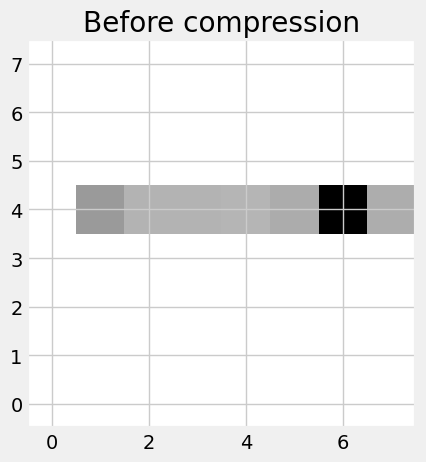

After: (1, 8, 8)
After compression
Perplexity: 1.7115646730390791e-28


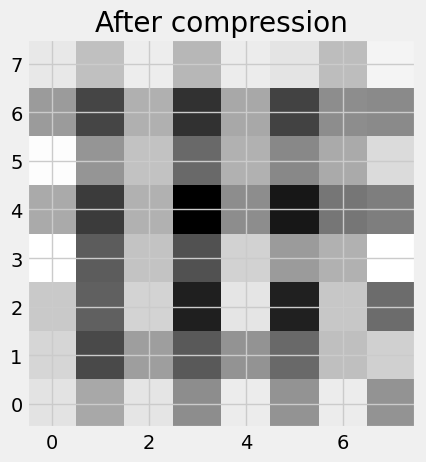

Epoch 2/80: 100%|██████████| 124/124 [00:00<00:00, 765.79it/s, Loss=407]


Epoch [2/80] Average Loss: 569.6693


Epoch 3/80: 100%|██████████| 124/124 [00:00<00:00, 780.83it/s, Loss=407]


Epoch [3/80] Average Loss: 569.5657


Epoch 4/80: 100%|██████████| 124/124 [00:00<00:00, 806.21it/s, Loss=406]


...

Epoch [9/80] Average Loss: 568.8807


Epoch 10/80: 100%|██████████| 124/124 [00:00<00:00, 793.83it/s, Loss=406]


Epoch [10/80] Average Loss: 568.7831


Epoch 11/80: 100%|██████████| 124/124 [00:00<00:00, 790.43it/s, Loss=406]


Epoch [11/80] Average Loss: 568.6934
Before compression
Before: (128, 8, 8)


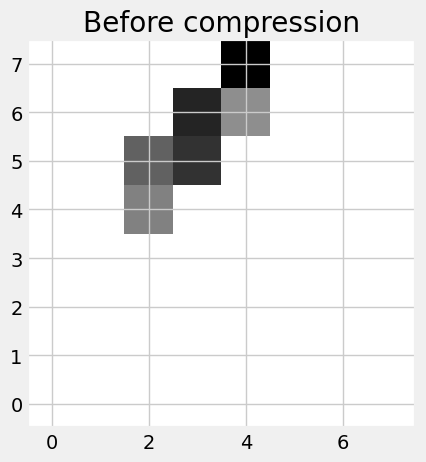

After: (1, 8, 8)
After compression
Perplexity: 1.7115646730390791e-28


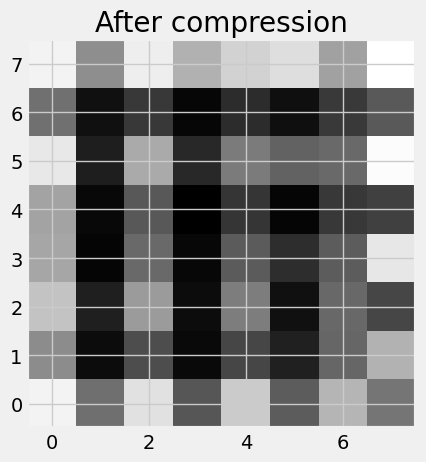

Epoch 12/80: 100%|██████████| 124/124 [00:00<00:00, 805.68it/s, Loss=406]


Epoch [12/80] Average Loss: 568.6110


Epoch 13/80: 100%|██████████| 124/124 [00:00<00:00, 823.33it/s, Loss=406]


Epoch [13/80] Average Loss: 568.5373


Epoch 14/80: 100%|██████████| 124/124 [00:00<00:00, 796.34it/s, Loss=406]


...

Epoch [19/80] Average Loss: 568.2312


Epoch 20/80: 100%|██████████| 124/124 [00:00<00:00, 783.77it/s, Loss=405]


Epoch [20/80] Average Loss: 568.1971


Epoch 21/80: 100%|██████████| 124/124 [00:00<00:00, 783.53it/s, Loss=405]


Epoch [21/80] Average Loss: 568.1659
Before compression
Before: (128, 8, 8)


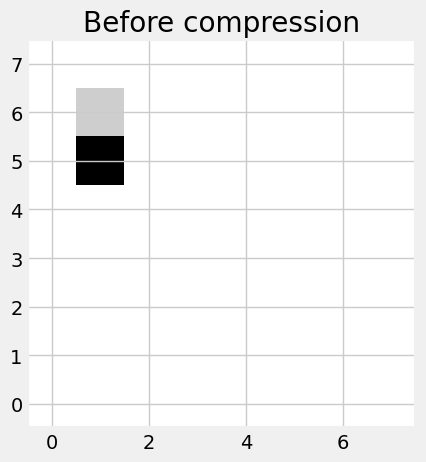

After: (1, 8, 8)
After compression
Perplexity: 1.7115646730390791e-28


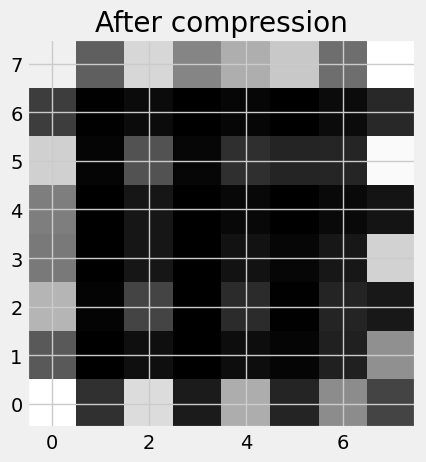

Epoch 22/80: 100%|██████████| 124/124 [00:00<00:00, 777.16it/s, Loss=405]


Epoch [22/80] Average Loss: 568.1354


Epoch 23/80: 100%|██████████| 124/124 [00:00<00:00, 786.23it/s, Loss=405]


Epoch [23/80] Average Loss: 568.1036


Epoch 24/80: 100%|██████████| 124/124 [00:00<00:00, 781.81it/s, Loss=405]


...

Epoch [29/80] Average Loss: 567.9494


Epoch 30/80: 100%|██████████| 124/124 [00:00<00:00, 780.17it/s, Loss=405]


Epoch [30/80] Average Loss: 567.9320


Epoch 31/80: 100%|██████████| 124/124 [00:00<00:00, 783.65it/s, Loss=405]


Epoch [31/80] Average Loss: 567.9161
Before compression
Before: (128, 8, 8)


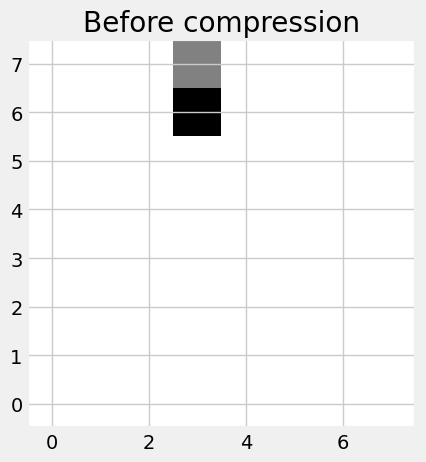

After: (1, 8, 8)
After compression
Perplexity: 1.7115646730390791e-28


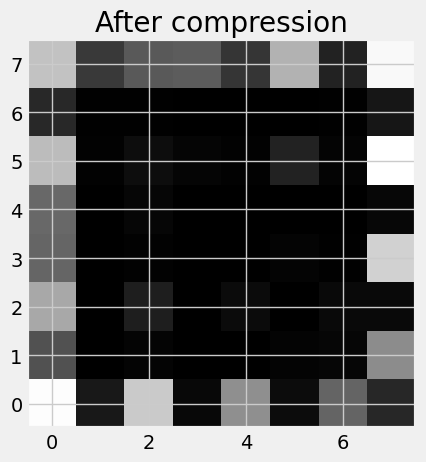

Epoch 32/80: 100%|██████████| 124/124 [00:00<00:00, 795.12it/s, Loss=405]


Epoch [32/80] Average Loss: 567.9013


Epoch 33/80: 100%|██████████| 124/124 [00:00<00:00, 787.88it/s, Loss=405]


Epoch [33/80] Average Loss: 567.8870


Epoch 34/80: 100%|██████████| 124/124 [00:00<00:00, 776.42it/s, Loss=405]


...

Epoch [39/80] Average Loss: 567.8131


Epoch 40/80: 100%|██████████| 124/124 [00:00<00:00, 813.78it/s, Loss=405]


Epoch [40/80] Average Loss: 567.8014


Epoch 41/80: 100%|██████████| 124/124 [00:00<00:00, 804.25it/s, Loss=405]


Epoch [41/80] Average Loss: 567.7912
Before compression
Before: (128, 8, 8)


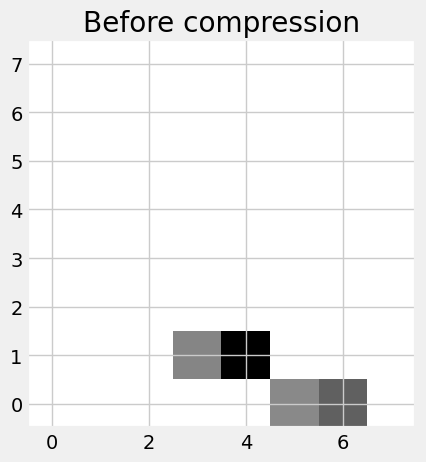

After: (1, 8, 8)
After compression
Perplexity: 1.7115646730390791e-28


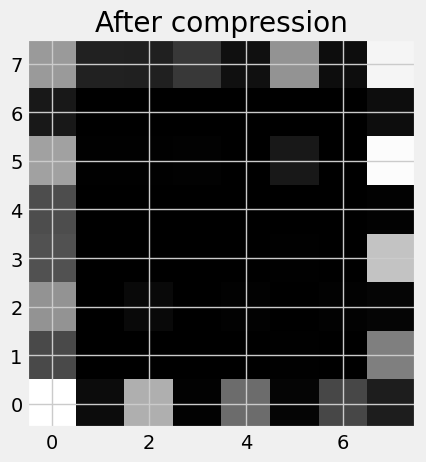

Epoch 42/80: 100%|██████████| 124/124 [00:00<00:00, 762.83it/s, Loss=405]


Epoch [42/80] Average Loss: 567.7808


Epoch 43/80: 100%|██████████| 124/124 [00:00<00:00, 771.15it/s, Loss=405]


Epoch [43/80] Average Loss: 567.7709


Epoch 44/80: 100%|██████████| 124/124 [00:00<00:00, 792.13it/s, Loss=405]


...

Epoch [49/80] Average Loss: 567.7188


Epoch 50/80: 100%|██████████| 124/124 [00:00<00:00, 793.66it/s, Loss=405]


Epoch [50/80] Average Loss: 567.7111


Epoch 51/80: 100%|██████████| 124/124 [00:00<00:00, 824.29it/s, Loss=405]


Epoch [51/80] Average Loss: 567.7039
Before compression
Before: (128, 8, 8)


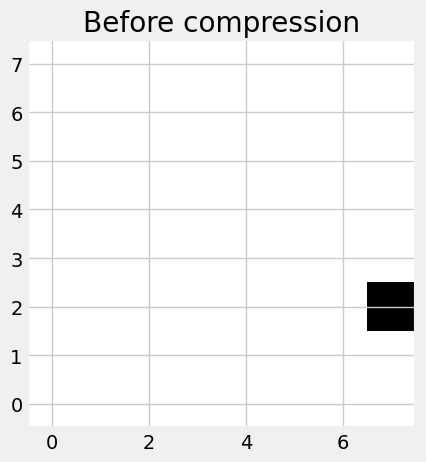

After: (1, 8, 8)
After compression
Perplexity: 1.7115646730390791e-28


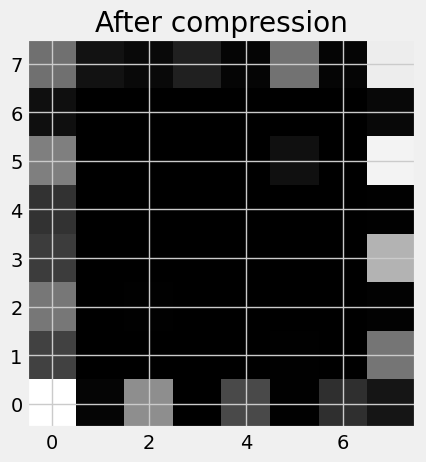

Epoch 52/80: 100%|██████████| 124/124 [00:00<00:00, 817.89it/s, Loss=405]


Epoch [52/80] Average Loss: 567.6966


Epoch 53/80: 100%|██████████| 124/124 [00:00<00:00, 818.40it/s, Loss=405]


Epoch [53/80] Average Loss: 567.6894


Epoch 54/80: 100%|██████████| 124/124 [00:00<00:00, 796.07it/s, Loss=405]


...

Epoch [59/80] Average Loss: 567.6538


Epoch 60/80: 100%|██████████| 124/124 [00:00<00:00, 760.48it/s, Loss=405]


Epoch [60/80] Average Loss: 567.6489


Epoch 61/80: 100%|██████████| 124/124 [00:00<00:00, 758.34it/s, Loss=405]


Epoch [61/80] Average Loss: 567.6442
Before compression
Before: (128, 8, 8)


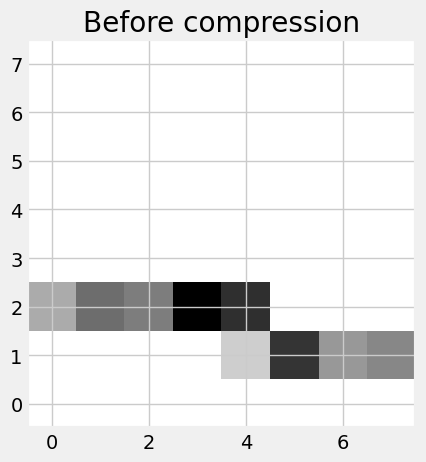

After: (1, 8, 8)
After compression
Perplexity: 1.7115646730390791e-28


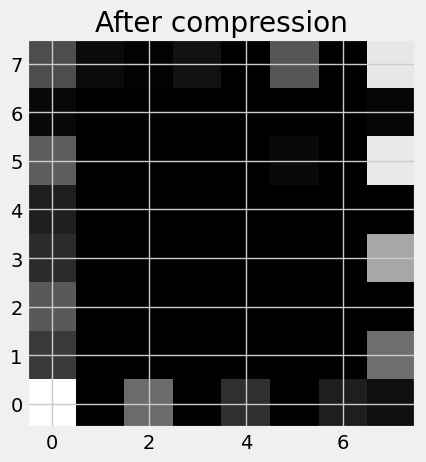

Epoch 62/80: 100%|██████████| 124/124 [00:00<00:00, 773.76it/s, Loss=405]


Epoch [62/80] Average Loss: 567.6394


Epoch 63/80: 100%|██████████| 124/124 [00:00<00:00, 782.21it/s, Loss=405]


Epoch [63/80] Average Loss: 567.6349


Epoch 64/80: 100%|██████████| 124/124 [00:00<00:00, 782.91it/s, Loss=405]


...

Epoch [69/80] Average Loss: 567.6118


Epoch 70/80: 100%|██████████| 124/124 [00:00<00:00, 781.14it/s, Loss=405]


Epoch [70/80] Average Loss: 567.6084


Epoch 71/80: 100%|██████████| 124/124 [00:00<00:00, 739.73it/s, Loss=405]


Epoch [71/80] Average Loss: 567.6044
Before compression
Before: (128, 8, 8)


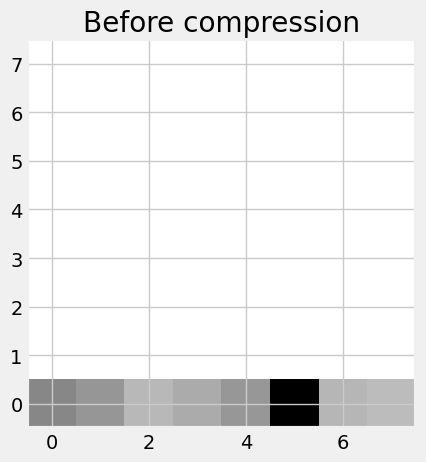

After: (1, 8, 8)
After compression
Perplexity: 1.7115646730390791e-28


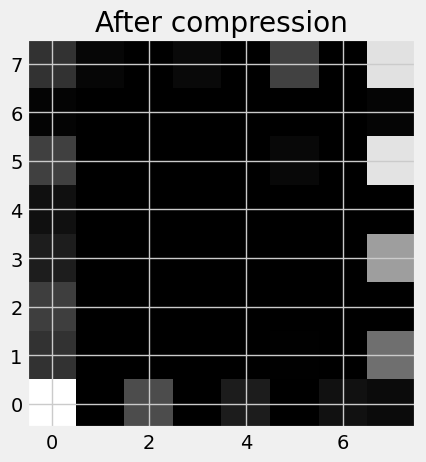

Epoch 72/80: 100%|██████████| 124/124 [00:00<00:00, 806.73it/s, Loss=405]


Epoch [72/80] Average Loss: 567.6012


Epoch 73/80: 100%|██████████| 124/124 [00:00<00:00, 816.46it/s, Loss=405]


Epoch [73/80] Average Loss: 567.5976


Epoch 74/80: 100%|██████████| 124/124 [00:00<00:00, 815.79it/s, Loss=405]


...

Epoch [78/80] Average Loss: 567.5800


Epoch 79/80: 100%|██████████| 124/124 [00:00<00:00, 814.08it/s, Loss=405]


Epoch [79/80] Average Loss: 567.5766


Epoch 80/80: 100%|██████████| 124/124 [00:00<00:00, 817.01it/s, Loss=405]

Epoch [80/80] Average Loss: 567.5727


In [162]:
# loss
average_loss_values = []
# ssim
ssim_values = []

# 6 * 6 * num_embeddings
# vienam bit uzkoduoti 25bit

# perplexity
perplexity_values = []

# Cutting after certain epochs
# scheduler = torch.optim.lr_scheduler.StepLR(
#     optimizer,
#     step_size=30,   # every 30 epochs
#     gamma=0.01       # multiply LR by 0.1
# )

# num_epochs = 20
idx_validation = 0
patch_test_cursor = iter(events_test_loaders[0])
model.train()

for epoch in range(num_epochs):
    train_loss = 0
    perplexity_per_epoch = 0
    
    # Use tqdm for the progress bar
    progress_bar = tqdm(
        enumerate(train_loader), 
        total=len(train_loader), 
        desc=f'Epoch {epoch+1}/{num_epochs}'
    )
    
    for (batch_idx, X_adcs) in progress_bar:
        optimizer.zero_grad()
        
        X_adcs = X_adcs.float()
        # X_adcs = X_adcs + 0.01 * torch.randn_like(X_adcs)
        X_adcs = X_adcs.to(device)
        
        
        X_adcs_tr = X_adcs.unsqueeze(1).permute(0, 1, 2, 3)
        
        # print(f"Inputing to model: {str(X_adcs.shape)}")
        
        # (
        #     recon_patch, 
        #     vq_loss, 
        #     perplexity, 
        #     _,
        #     _
        # ) = model(
        #    X_adcs_tr
        # )
        (
            recon_patch, 
            vq_loss, 
            perplexity,
            encodings,
            codebooks
        ) = model(
           X_adcs_tr
        )
        
        recon_patch = recon_patch.float().to(device)      
        
        loss = _get_vq_loss(recon_patch, X_adcs_tr, vq_loss)
        loss.backward()
        train_loss += loss.item()
        perplexity_per_epoch += perplexity.item()
        
        optimizer.step()        

        # Update tqdm description with current loss
        progress_bar.set_postfix({'Loss': loss.item()})
        # scheduler.step()
        
        
    # Saving epoch  statistics
    
    avg_loss = train_loss / len(train_loader)
    average_loss_values.append(avg_loss)
    perplexity_values.append(perplexity_per_epoch / len(train_loader))
    print(f'Epoch [{epoch + 1}/{num_epochs}] Average Loss: {avg_loss:.4f}')
    
    if epoch % LOG_EVERY == 0:
        with torch.no_grad():            
            # selecting events before reconstruction using one test loader as validation
            patch_test = next(patch_test_cursor) 
            patch_test = patch_test.to(device)           
            print("Before compression")
            
            patch_test_ts = _tensor_to_numpy(
                patch_test.squeeze(1)
            )
            
            
            print(f"Before: {patch_test_ts.shape}")            
            plot_patch(patch_test_ts[0], "Before compression")
            
            # (
            #     recon_patch, 
            #     _, 
            #     perplexity, 
            #     _,
            #     _              
            # ) = model(patch_test)
            (
                recon_patch, 
                vq_loss, 
                perplexity, 
                encodings,
                codebooks         
            ) = model(patch_test)
            
            recon_patch_np = _tensor_to_numpy(
                recon_patch[0]
            )
            print(f"After: {recon_patch_np.shape}")
            print("After compression")
            
            print(f"Perplexity: {perplexity}")
            
            plot_patch(recon_patch_np[0], "After compression")
        

In [163]:
# Test model with unseen data
events_test_patches_adcs = [
    event_hits_to_patches(event, PATCH_SIZE).as_array()
    for event in events_test[:SELECTED_EVENTS]
]

events_test_patches = [
    event_hits_to_patches(event, PATCH_SIZE)
    for event in events_test[:SELECTED_EVENTS]
]
print(f"Events test: {len(events_test_patches_adcs)}")
print(f"Event patches: {len(events_test_patches[0])}")


Events test: 1
Event patches: 8452


In [164]:
X_test_patch = events_test_patches_adcs[0][0]
X_test = torch.tensor(X_test_patch).to(device).float()
X_test = X_test.reshape(
    PATCH_SIZE, 
    PATCH_SIZE
).unsqueeze(1).permute(1, 0, 2).unsqueeze(1)


In [165]:
X_test.shape

torch.Size([1, 1, 8, 8])

In [166]:
model.eval()

print("Compression quality measurements")

#    return (
#            x_recon, 
#            vq_loss, 
#            perplexity,        
#            encodings
#         )

with torch.no_grad():
    model = VQVAE(
        hidden_channels = 4,
        kernel_size = 4,
        slope = 0.05 
    ).to(device)
    X_test = X_test.permute(1, 0, 2, 3)
    print(X_test.shape)
    z = model.encoder(X_test)
    # z, vq_loss, perplexity, encodings, _ = model.vq_layer(z)
    z_q, loss, perplexity, encodings, _ = model.vq_layer(z)
    
    print("Encoded patch:")
    print(encodings)
    
    print(f"Latent shape: {z_q.shape}")
    
    used_codes = torch.unique(encodings)
    num_used = used_codes.numel()
    
    print(f"Codebook unique encodings:{len(used_codes)}")
    print(encodings.shape)
    print(encodings.unique())
    
    codebook = model.vq_layer.embedding.weight
    codebook_size = codebook.element_size() * codebook.numel()
    
    print(f"Codebook size: {len(used_codes)}")
    
    # X_test_bits = _get_bits_from_tensor(X_test)
    
    # compression_ratio = _get_compression_ratio(X_test, num_embeddings, encodings.numel())
    # print(f"Compression ratio: {compression_ratio}")
    
    # patch_bits = _get_patch_bits(num_embeddings, encodings.numel())
    # print(f"Tensor bits: {X_test_bits}")
    # print(f"Used patch bits: {patch_bits}")
    
    # TOtal codebook size
    print(f"Embedding size: {encodings.numel()}")
    print(f"Embedding shape: {encodings.shape}")
    print(f"Encodings: {encodings}")
    
    n_hits_total = 0
    for event_test in events_test[:SELECTED_EVENTS]:
        n_hits_total += len(event_test)
    
        
    print(f"Test event hits: {n_hits_total}")
    total_hit_bits = _get_total_hit_bits(n_hits_total)
    print(f"Total hit bits: {total_hit_bits}")
    
    patch_amount = _get_patch_count(events_test[0])
    print(f"Patch amount: {patch_amount}")
    
    total_patch_bits = _get_total_patch_bits(
        patch_amount=patch_amount,
        encoded_patch_size=(encodings.numel(), 1, num_embeddings),
        patch_size=PATCH_SIZE
    )
    print(f"Total patch bits: {total_patch_bits}")
    
    compression_ratio = _get_compression_ratio(
        n_hits_total, 
        patch_amount,
        (encodings.numel(), 1, num_embeddings),
        PATCH_SIZE
    )
    print(f"Compression ratio: {compression_ratio}")
    
    encoded_patch_bits = _get_encoded_patch_bits((encodings.numel(), 1, num_embeddings), PATCH_SIZE)
    print(f"Encoded patch: {encoded_patch_bits} bits")
    
    # print(len(train_loader) + len(events_test_loaders[0]))
    # print(_get_encoded_patch_bits((encodings.numel(), 1, num_embeddings), PATCH_SIZE))
    
    # print(encodings.shape)
    

Compression quality measurements
torch.Size([1, 1, 8, 8])
Encoded patch:
tensor([27, 27, 27, 27, 27, 27, 27, 27, 97, 93, 93, 26, 27, 27, 27, 27],
       device='cuda:0')
Latent shape: torch.Size([1, 64, 4, 4])
Codebook unique encodings:4
torch.Size([16])
tensor([26, 27, 93, 97], device='cuda:0')
Codebook size: 4
Embedding size: 16
Embedding shape: torch.Size([16])
Encodings: tensor([27, 27, 27, 27, 27, 27, 27, 27, 97, 93, 93, 26, 27, 27, 27, 27],
       device='cuda:0')
Test event hits: 24791
Total hit bits: 619775
Patch amount: 8452
Total patch bits: 1039596
Compression ratio: 0.5961690887614035
Encoded patch: 123 bits


In [167]:
events_test[0].det_ids

array([303042564, 303042564, 303042564, ..., 353339396, 353339396,
       353339396], shape=(24791,), dtype=int32)

/tmp/ipykernel_3632064/2586957935.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Average reconstruction loss over epochs values over epochs


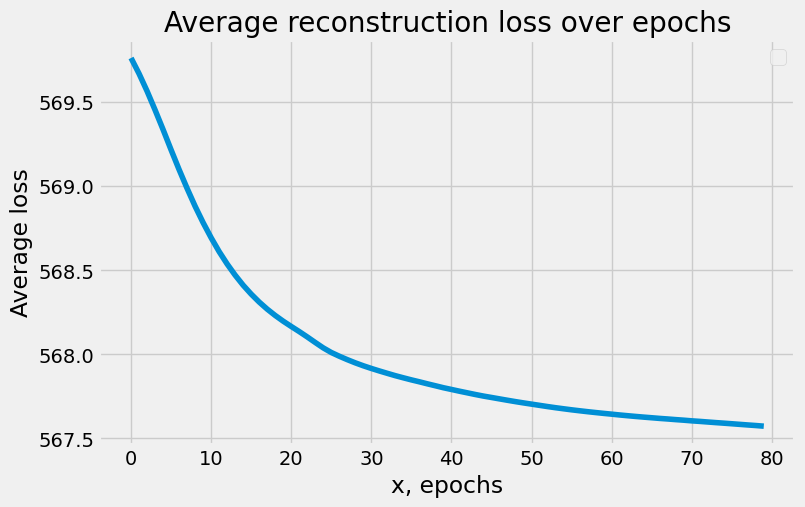

In [168]:
plot_metric_results(
    average_loss_values, 
    list(range(num_epochs)), 
    "Average loss", 
    "Average reconstruction loss over epochs",
    "x, epochs"
)

In [169]:
torch.save(model.state_dict(), "vq_vae_pileup.pth")

In [170]:
# TODO: change debug for option change event_hit_test count
# def _get_reshape_tensor(patch_flatten: np.array) -> torch.tensor:
#     patch = patch_flatten.reshape(PATCH_SIZE, PATCH_SIZE)
#     patch_tensor_ini = torch.tensor(patch)
#     # patch_tensor = patch_tensor_ini.unsqueeze(1).unsqueeze(1).transpose(0, 2)
#     patch_tensor = patch_tensor_ini.unsqueeze(1)
#     patch_tensor = patch_tensor.float()
#     patch_tensor = patch_tensor.to(device)
#     return patch_tensor

# events_test_patches_tensors = []
# for event_test_patches_adcs in events_test_patches_adcs:
#     event_test_patches_tensors = list(map(_get_reshape_tensor, event_test_patches_adcs))
#     event_test_patch_first = event_test_patches_tensors[0]
#     print(f"DEBUG: first event shape: {event_test_patch_first.shape}")
    
#     events_test_patches_tensors.append(event_test_patches_tensors)

In [171]:
# len(event_test_patches_tensors)

Perplexity: 2.2551670718749654e-39
Patch compression statistics
Before: torch.Size([128, 1, 8, 8])
After compression
After: (128, 8, 8)


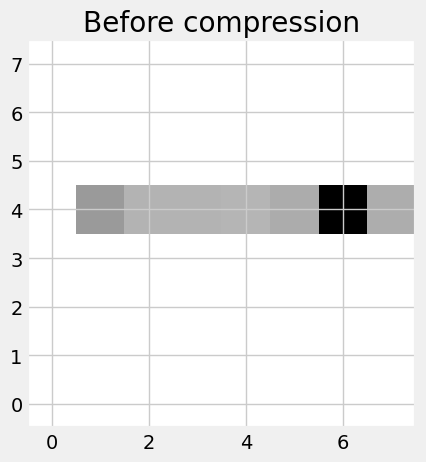

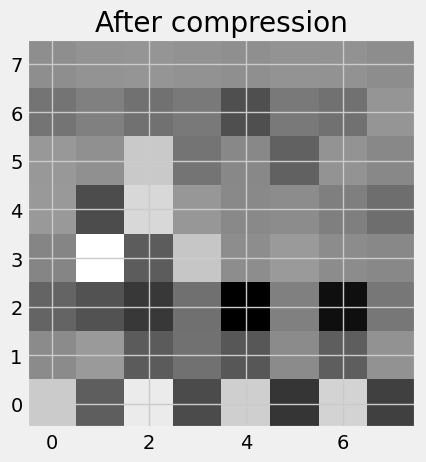

Adding adcs shape: (64,)
Perplexity: 1.9801216105957547e-39
Patch compression statistics
Before: torch.Size([128, 1, 8, 8])
After compression
After: (128, 8, 8)


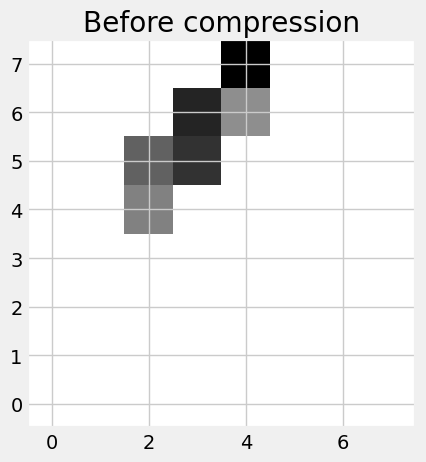

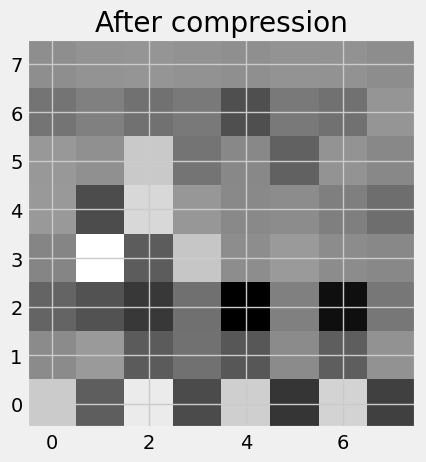

Adding adcs shape: (64,)
Perplexity: 2.2551670718749654e-39
Patch compression statistics
Before: torch.Size([128, 1, 8, 8])
After compression
After: (128, 8, 8)
Adding adcs shape: (64,)
Perplexity: 2.2551670718749654e-39
Patch compression statistics
Before: torch.Size([128, 1, 8, 8])
After compression
After: (128, 8, 8)
Adding adcs shape: (64,)
Perplexity: 1.9801216105957547e-39
Patch compression statistics
Before: torch.Size([128, 1, 8, 8])
After compression
After: (128, 8, 8)
Adding adcs shape: (64,)
Perplexity: 2.2551670718749654e-39
Patch compression statistics
Before: torch.Size([128, 1, 8, 8])
After compression
After: (128, 8, 8)
Adding adcs shape: (64,)
Perplexity: 2.2551670718749654e-39
Patch compression statistics
Before: torch.Size([128, 1, 8, 8])
After compression
After: (128, 8, 8)
Adding adcs shape: (64,)
Perplexity: 2.2551670718749654e-39
Patch compression statistics
Before: torch.Size([128, 1, 8, 8])
After compression
After: (128, 8, 8)
Adding adcs shape: (64,)
Perplexit

In [200]:
# Performing test on unseen data
plot_patches_debug = 2
plotted_patches = 0
fill_value = 0
decompressed_events = []
T_SIMILAR = 0.7
T_DISSIMILAR = 0
T_IDENTICAL = 0.9
T_CODEBOOK = 2

model.load_state_dict(torch.load("vq_vae_pileup.pth"))
model = model.to(device)
# model.eval() 

# compressing patches
events_test_patches = [
    event_hits_to_patches(event, PATCH_SIZE)
    for event in events_test
]

# compressing / decompressing each event patch adcs
for (i, event_test_loader) in enumerate(events_test_loaders):
    event_adcs_merged = []
    
    for (j, event_patch) in enumerate(event_test_loader):
        with torch.no_grad():
            event_patch = event_patch.to(device)
            
            # (
            #     recon_patch, 
            #     _, 
            #     _, 
            #     z_q,
            #     _
            # ) = model(event_patch)
        #             return (
        #    x_recon, 
        #    vq_loss, 
        #    perplexity,        
        #    encodings
        # )
            (
                recon_patch, 
                _, 
                perplexity, 
                encodings,
                codebooks
            ) = model(event_patch)
            
            print(f"Perplexity: {perplexity}")
            
            # Reconstructed adcs
            patch_original = _tensor_to_numpy(
                event_patch.squeeze(1)
            )
            
            recon_patch_np = _tensor_to_numpy(
                recon_patch.squeeze(1)
            )
            
            # compression_ratio = _get_compression_ratio(
            #     a=event_patch,
            #     b=z_q,
            #     precision=10
            # )
            
            print("Patch compression statistics")
            print(f"Before: {event_patch.shape}")
            print("After compression")
            print(f"After: {recon_patch_np.shape}")            
            # print(f"Event Patch {j + 1} compression ratio (original/q_latent): {compression_ratio}")
            
            if plotted_patches < plot_patches_debug:
                plot_patch(patch_original[0], "Before compression")        
                plot_patch(recon_patch_np[0], "After compression")
                plotted_patches += 1
            
            # compression_ratio_values.append(compression_ratio)
            
            adcs_decoded = recon_patch_np[0].flatten()
            print(f"Adding adcs shape: {adcs_decoded.shape}")
            event_adcs_merged.append(adcs_decoded)
    
    # saving new decompressed
    # checking occupancy
    X_patches = np.concatenate(event_adcs_merged)
    X_occupancy = (X_patches != fill_value)
    
    event_test_patches = events_test_patches[i]
    
    # # Make the first decompressed event
    event_patches_decompressed = PixelEventPatches(
        detector=pix_det,
        patch_size=PATCH_SIZE,
        event_id=event_test_patches.event_id,
        det_ids=event_test_patches.det_ids,
        rows=event_test_patches.rows,
        cols=event_test_patches.cols,
        adcs=np.round(X_patches * 255),
        occupancy=X_occupancy
    )
    event_hits = event_patches_to_hits(
        event_patches_decompressed
    )
    decompressed_events.append(event_hits)
    
    print(f"Showing event_id = {event_hits.id_} statistics")
    
    event_codebooks_high = sum([perplexity > T_CODEBOOK for perplexity in perplexity_values])
    event_codebooks_low = sum([perplexity < T_CODEBOOK for perplexity in perplexity_values])
    
    print("-----------")
    print(f"Above limit: {T_CODEBOOK}, codebook count: {event_codebooks_high}")
    print(f"Lower limit: {T_CODEBOOK}, codebook count: {event_codebooks_low}")
    
    print(f"Showing decompressed vs original patches ssim:")
    
    identical_count = sum(list(map(lambda x: x > T_IDENTICAL, ssim_values)))
    similar_count = sum(list(map(lambda x: x > T_SIMILAR and x < T_IDENTICAL, ssim_values)))
    dissimilar_count = sum(list(map(lambda x: x < T_DISSIMILAR, ssim_values)))
    
    print("-----------")
    print(f"Identical patches: {identical_count}")
    print(f"Similar patches: {similar_count}")
    print(f"Dissimilar patches: {dissimilar_count}")
    print("-----------")  

In [ ]:
# next(iter(events_test_loaders[0]))[0][0].flatten().shape

torch.Size([64])

Event test before compression


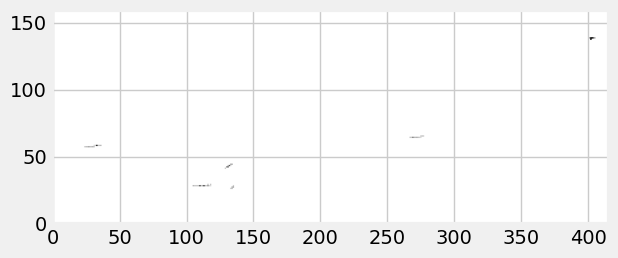

In [173]:
print("Event test before compression")
for event_test in events_test[:SELECTED_EVENTS]:
    show_image(event_test)

Event test after compression


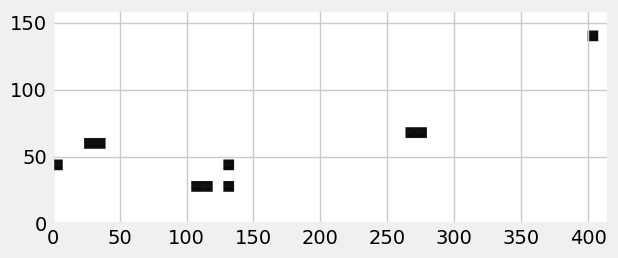

In [174]:
print("Event test after compression")
for event_test in decompressed_events[:SELECTED_EVENTS]:
    show_image(event_test)

In [175]:
len(decompressed_events)

1

<h2>Event compression statistics<h2>

In [176]:
# hit count in original events
n_hits_total = 0
for event_test in events_test[:SELECTED_EVENTS]:
    n_hits_total += len(event_test)
    
print(f"Selected events have hits: {n_hits_total}")

Selected events have hits: 24791


In [177]:
# hit count in original events
n_hits_total_vq = 0
for decomp_event_test in decompressed_events[:SELECTED_EVENTS]:
    # print(np.unique(decomp_event_test.det_ids))
    # print([len(hit) for hit in decomp_event_test.hits])
    n_hits_total_vq += len(decomp_event_test)
    
print(f"Decompressed events have hits: {n_hits_total_vq}")

Decompressed events have hits: 540928


In [186]:
events_test[0].hits[0].adcs.shape

(62,)

In [185]:
# FIXME: it should not be this many
decompressed_events[0].hits[0].adcs.shape

(640,)

<h1>VQ-VAE compression metrics</h1>

In [180]:
# for i in range(SELECTED_EVENTS):
#     event = events_test[i]
#     result = 
#         event,
#         decompressed_events[i]
#     )
#     print(f"Event ID = {event.id_}")
#     print(result)

# Showing test vs reconstructed events
event_hits_metrics(
   events_test[:SELECTED_EVENTS],
   decompressed_events[:SELECTED_EVENTS] 
)

{'rmse': 66.84923569121788,
 'mae': 58.61768341064453,
 'mismatch_ratio': 0.9968536969061353,
 'reco_precision_recall': (0.04583049869853289, 1.0)}

Perplexity (code books per epochs) values over epochs


/tmp/ipykernel_3632064/2586957935.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


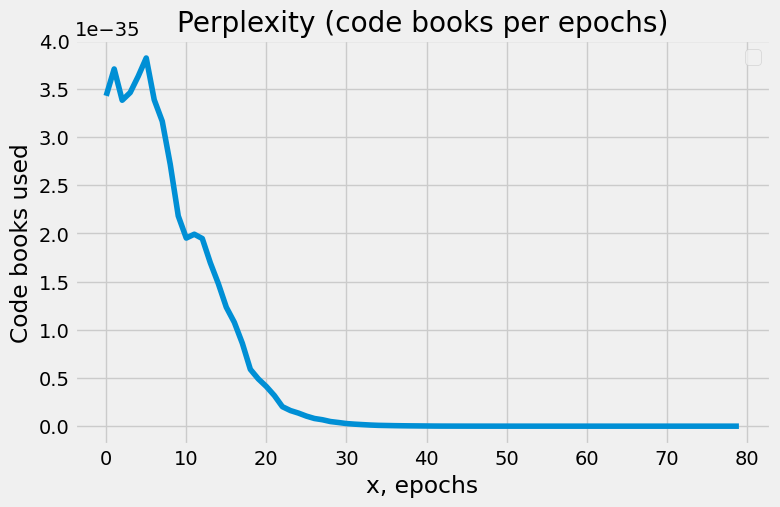

In [181]:
# perplexity
plot_metric_results(
    perplexity_values, 
    list(range(num_epochs)), 
    "Code books used", 
    "Perplexity (code books per epochs)",
    "x, epochs"
)

In [182]:
# len(perplexity_values)
events_test_patches = [
    event_hits_to_patches(event, PATCH_SIZE)
    for event in events_test
]

In [183]:
events_test_patches[0].adcs[0]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,  75,  56,  56,  55,  62, 189,
        61,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
      dtype=uint8)